# AI Hallucination Visualizer: Mapping Uncertainty in Language Models

Language models generate text by predicting the next token in a sequence. At each step, the model assigns a probability to every possible continuation and picks one. Sometimes the model is very confident in its choice. Sometimes it is guessing.

The problem is that **confidence does not equal correctness**. A model can produce a completely wrong answer with 80% confidence, or a perfectly valid answer with only 10% confidence. This notebook walks through how to extract and visualize those confidence scores so you can see exactly where a model is reliable and where it might be hallucinating.

We will:
1. Load GPT-2 and generate text
2. Extract per-token probabilities from the model's internal scores
3. Classify each token's confidence level
4. Visualize the results with color-coded tokens and charts

**GitHub**: [archit-konde/ai-hallucination-visualizer](https://github.com/archit-konde/ai-hallucination-visualizer)  

**Live Demo**: [HuggingFace Spaces](https://huggingface.co/spaces/architechs/ai-hallucination-visualizer)

**Authors**: [Amey Thakur](https://www.kaggle.com/ameythakur20) & [Archit Konde](https://www.kaggle.com/architkonde)

## 1. Setup

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import HTML, display
from transformers import AutoModelForCausalLM, AutoTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 2. Load GPT-2

GPT-2 is a decoder-only transformer with 124 million parameters and a vocabulary of 50,257 tokens (byte-pair encoding). It was released by OpenAI in 2019 and is small enough to run on a free Kaggle CPU kernel.

We load it in evaluation mode since we only need inference, not training.

In [2]:
MODEL_NAME = "openai-community/gpt2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.eval()
model.to(device)

print(f"Model: {MODEL_NAME}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Vocabulary size: {tokenizer.vocab_size:,}")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model: openai-community/gpt2
Parameters: 124,439,808
Vocabulary size: 50,257


## 3. Generate Text with Score Tracking

The key to this whole approach is passing `output_scores=True` to `model.generate()`. This tells the model to return the raw logit scores at every generation step, not just the final text. Each score tensor has shape `(1, vocab_size)` and contains the unnormalized log-odds for every possible next token.

We also pass `return_dict_in_generate=True` so the output is a structured object instead of just a tensor of token IDs.

In [3]:
prompt = "The capital of France is"
max_tokens = 50

inputs = tokenizer(prompt, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_tokens,
        do_sample=False,
        return_dict_in_generate=True,
        output_scores=True,
    )

generated_text = tokenizer.decode(outputs.sequences[0], skip_special_tokens=True)
print(f"Prompt: {prompt}")
print(f"Generated: {generated_text}")
print(f"\nScores collected: {len(outputs.scores)} steps")
print(f"Each score shape: {outputs.scores[0].shape}")

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Prompt: The capital of France is
Generated: The capital of France is the capital of the French Republic, and the capital of the French Republic is the capital of the French Republic.

The French Republic is the capital of the French Republic.

The French Republic is the capital of the French Republic.



Scores collected: 50 steps
Each score shape: torch.Size([1, 50257])


## 4. Extract Per-Token Probabilities

Now we use `compute_transition_scores` to get the log-probability of each token that was actually selected. The `normalize_logits=True` flag applies log-softmax internally, so the returned values are proper log-probabilities (not raw logits).

We then convert to regular probabilities with `exp()` and extract the top-5 alternative tokens the model considered at each step.

In [4]:
# Get log-probabilities for selected tokens
transition_scores = model.compute_transition_scores(
    outputs.sequences, outputs.scores, normalize_logits=True
)

input_length = outputs.sequences.shape[1] - len(outputs.scores)
generated_ids = outputs.sequences[0, input_length:]

# Build token data with probabilities and alternatives
token_data = []

for step in range(len(outputs.scores)):
    token_id = generated_ids[step].item()
    log_prob = transition_scores[0, step].item()
    prob = torch.exp(transition_scores[0, step]).item()
    text = tokenizer.decode([token_id])

    # Get top-5 alternatives at this step
    step_probs = F.softmax(outputs.scores[step][0], dim=-1)
    top_values, top_indices = torch.topk(step_probs, 6)
    alternatives = []
    for val, idx in zip(top_values, top_indices):
        if idx.item() != token_id:
            alternatives.append({
                "text": tokenizer.decode([idx.item()]),
                "probability": round(val.item(), 4),
            })
        if len(alternatives) >= 5:
            break

    token_data.append({
        "text": text,
        "token_id": token_id,
        "probability": round(prob, 4),
        "log_probability": round(log_prob, 4),
        "alternatives": alternatives,
    })

# Show a preview
print(f"{'Token':<15} {'Probability':>12} {'Log Prob':>10}")
print("-" * 40)
for t in token_data[:10]:
    print(f"{repr(t['text']):<15} {t['probability']:>11.4f} {t['log_probability']:>10.4f}")
if len(token_data) > 10:
    print(f"... ({len(token_data) - 10} more tokens)")

Token            Probability   Log Prob
----------------------------------------
' the'               0.0846    -2.4699
' capital'           0.1697    -1.7738
' of'                0.9271    -0.0757
' the'               0.2828    -1.2631
' French'            0.1367    -1.9901
' Republic'          0.3006    -1.2019
','                  0.3391    -1.0814
' and'               0.2810    -1.2695
' the'               0.1634    -1.8118
' capital'           0.1052    -2.2520
... (40 more tokens)


## 5. Classify Confidence Levels

We classify each token into three confidence tiers:

| Level | Probability | Meaning |
|-------|------------|---------|
| **High** | > 60% | The model strongly preferred this token |
| **Medium** | 30-60% | A few plausible options existed |
| **Low** | < 30% | The model was guessing -- potential hallucination |

These thresholds are empirical starting points, not universal rules.

In [5]:
HIGH_THRESHOLD = 0.6
MEDIUM_THRESHOLD = 0.3

def classify_confidence(probability):
    if probability > HIGH_THRESHOLD:
        return "high"
    if probability >= MEDIUM_THRESHOLD:
        return "medium"
    return "low"

for t in token_data:
    t["confidence"] = classify_confidence(t["probability"])

# Summary statistics
counts = {"high": 0, "medium": 0, "low": 0}
for t in token_data:
    counts[t["confidence"]] += 1

avg_conf = np.mean([t["probability"] for t in token_data])
print(f"Total tokens: {len(token_data)}")
print(f"Average confidence: {avg_conf:.1%}")
print(f"High: {counts['high']}  |  Medium: {counts['medium']}  |  Low: {counts['low']}")

Total tokens: 50
Average confidence: 56.1%
High: 21  |  Medium: 15  |  Low: 14


## 6. Visualize: Color-Coded Tokens

This is the core visualization. Each token is displayed as an inline span with a background color reflecting its confidence level -- green for high, yellow for medium, red for low. You can immediately see where the model was confident and where it was uncertain.

In [6]:
COLORS = {
    "high": "#22c55e",    # green-500 (vivid)
    "medium": "#eab308",  # yellow-500 (vivid)
    "low": "#ef4444",     # red-500 (vivid)
}

COLORS_BG = {
    "high": "#166534",    # green-800 (dark background)
    "medium": "#854d0e",  # yellow-800 (dark background)
    "low": "#991b1b",     # red-800 (dark background)
}

def render_tokens_html(token_data, title=""):
    """Render color-coded tokens as inline HTML, readable on both light and dark themes."""
    html = '<div style="font-family: monospace; font-size: 14px; line-height: 2.2; '
    html += 'background: #1f2937; padding: 16px; border-radius: 8px; margin: 8px 0;">'
    if title:
        html += f'<div style="font-size: 12px; color: #d1d5db; margin-bottom: 10px; '
        html += f'font-family: sans-serif; font-weight: 600;">{title}</div>'

    for t in token_data:
        bg = COLORS_BG[t["confidence"]]
        fg = COLORS[t["confidence"]]
        tooltip = f"{repr(t['text'])} | prob: {t['probability']:.1%} | {t['confidence']}"
        html += f'<span title="{tooltip}" style="background: {bg}; color: {fg}; '
        html += f'padding: 2px 4px; border-radius: 3px; cursor: default; '
        html += f'font-weight: 600;">'
        html += f'{t["text"]}</span>'

    html += '</div>'

    # Legend
    html += '<div style="font-size: 12px; color: #d1d5db; font-family: sans-serif; '
    html += 'display: flex; gap: 16px; margin-top: 6px; font-weight: 500;">'
    for level, color in COLORS.items():
        label = {"high": "High (>60%)", "medium": "Medium (30-60%)", "low": "Low (<30%)"}[level]
        html += f'<span><span style="display: inline-block; width: 12px; height: 12px; '
        html += f'background: {color}; border-radius: 3px; margin-right: 5px; '
        html += f'vertical-align: middle;"></span>{label}</span>'
    html += '</div>'

    return html

display(HTML(render_tokens_html(token_data, title=f'Prompt: "{prompt}"')))

## 7. Visualize: Confidence Chart

This chart shows the probability of each generated token plotted by position. The dashed lines mark the confidence boundaries at 60% and 30%. Dips below the red line indicate tokens where the model had very low confidence -- these are the most likely candidates for hallucination.

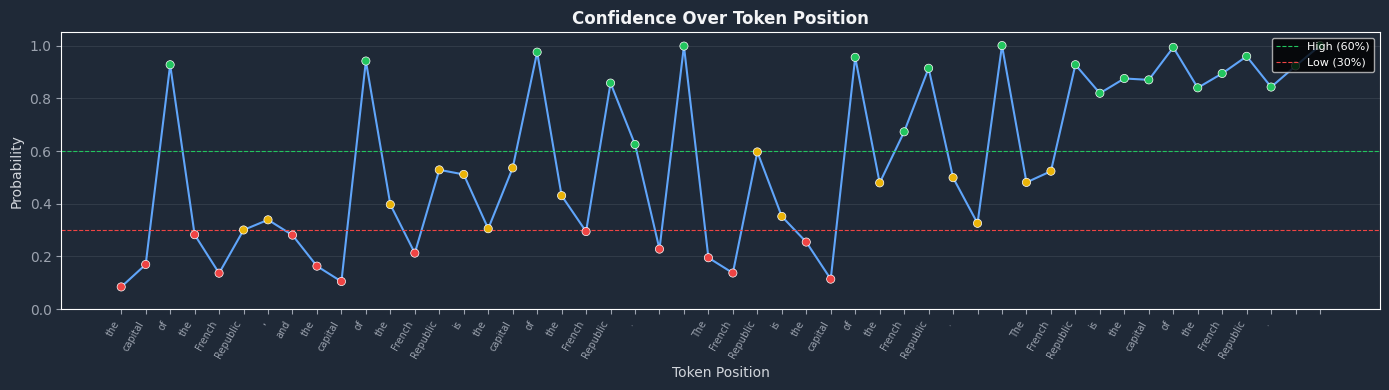

In [7]:
def plot_confidence_chart(token_data, title="Confidence Over Token Position"):
    """Plot per-token probability with confidence threshold lines."""
    probs = [t["probability"] for t in token_data]
    labels = [t["text"].strip() or t["text"] for t in token_data]
    colors = [COLORS[t["confidence"]] for t in token_data]
    positions = range(len(probs))

    plt.style.use("dark_background")
    fig, ax = plt.subplots(figsize=(14, 4))
    fig.patch.set_facecolor("#1f2937")
    ax.set_facecolor("#1f2937")

    ax.plot(positions, probs, color="#60a5fa", linewidth=1.5, zorder=2)
    ax.scatter(positions, probs, c=colors, edgecolors="white",
               linewidths=0.5, s=35, zorder=3)

    ax.axhline(y=0.6, color="#22c55e", linestyle="--", linewidth=0.8, label="High (60%)")
    ax.axhline(y=0.3, color="#ef4444", linestyle="--", linewidth=0.8, label="Low (30%)")

    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Token Position", fontsize=10, color="#d1d5db")
    ax.set_ylabel("Probability", fontsize=10, color="#d1d5db")
    ax.set_title(title, fontsize=12, fontweight="bold", color="#f3f4f6")
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=60, ha="right", fontsize=7, color="#9ca3af")
    ax.tick_params(colors="#9ca3af")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(axis="y", alpha=0.15, color="#9ca3af")

    plt.tight_layout()
    plt.show()
    plt.style.use("default")

plot_confidence_chart(token_data)

## 8. Inspect Alternatives at Low-Confidence Tokens

When the model has low confidence, it means several tokens were competing for the top spot. Looking at the alternatives tells us what the model was "thinking about" at that position. This is especially revealing at hallucination-prone tokens.

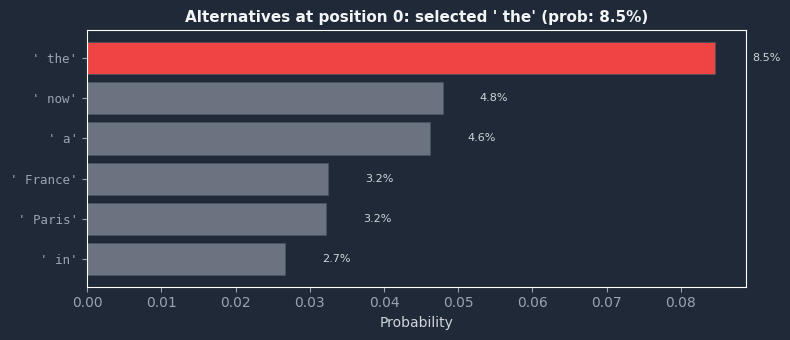

In [8]:
def plot_alternatives(token_data):
    """Find the lowest-confidence token and show its alternatives."""
    lowest = min(token_data, key=lambda t: t["probability"])
    idx = token_data.index(lowest)

    items = [{"text": lowest["text"], "prob": lowest["probability"]}]
    for alt in lowest["alternatives"]:
        items.append({"text": alt["text"], "prob": alt["probability"]})

    texts = [repr(x["text"]) for x in items]
    probs = [x["prob"] for x in items]
    bar_colors = ["#ef4444"] + ["#6b7280"] * (len(items) - 1)

    plt.style.use("dark_background")
    fig, ax = plt.subplots(figsize=(8, 3.5))
    fig.patch.set_facecolor("#1f2937")
    ax.set_facecolor("#1f2937")

    bars = ax.barh(range(len(items)), probs, color=bar_colors, edgecolor="#4b5563", linewidth=0.5)
    ax.set_yticks(range(len(items)))
    ax.set_yticklabels(texts, fontsize=9, fontfamily="monospace", color="#d1d5db")
    ax.set_xlabel("Probability", fontsize=10, color="#d1d5db")
    ax.set_title(f"Alternatives at position {idx}: selected {repr(lowest['text'])} "
                 f"(prob: {lowest['probability']:.1%})",
                 fontsize=11, fontweight="bold", color="#f3f4f6")
    ax.invert_yaxis()
    ax.tick_params(colors="#9ca3af")

    for bar, p in zip(bars, probs):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{p:.1%}", va="center", fontsize=8, color="#d1d5db")

    plt.tight_layout()
    plt.show()
    plt.style.use("default")

plot_alternatives(token_data)

## 9. Try Different Prompts

Let's wrap everything into a reusable function and compare how the model behaves on different types of prompts. Factual prompts tend to start confident and then lose confidence as the model ventures further from known facts. Creative prompts often have lower baseline confidence throughout.

In [9]:
def analyze_prompt(prompt, max_tokens=40):
    """Run the full pipeline: generate, extract probabilities, visualize."""
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False,
            return_dict_in_generate=True,
            output_scores=True,
        )

    transition_scores = model.compute_transition_scores(
        outputs.sequences, outputs.scores, normalize_logits=True
    )

    input_length = outputs.sequences.shape[1] - len(outputs.scores)
    generated_ids = outputs.sequences[0, input_length:]

    data = []
    for step in range(len(outputs.scores)):
        token_id = generated_ids[step].item()
        prob = torch.exp(transition_scores[0, step]).item()
        log_prob = transition_scores[0, step].item()

        step_probs = F.softmax(outputs.scores[step][0], dim=-1)
        top_vals, top_idxs = torch.topk(step_probs, 6)
        alts = []
        for v, i in zip(top_vals, top_idxs):
            if i.item() != token_id:
                alts.append({"text": tokenizer.decode([i.item()]), "probability": round(v.item(), 4)})
            if len(alts) >= 5:
                break

        data.append({
            "text": tokenizer.decode([token_id]),
            "token_id": token_id,
            "probability": round(prob, 4),
            "log_probability": round(log_prob, 4),
            "confidence": classify_confidence(prob),
            "alternatives": alts,
        })

    avg = np.mean([t["probability"] for t in data])
    display(HTML(render_tokens_html(data, title=f'Prompt: "{prompt}" | Avg confidence: {avg:.1%}')))
    plot_confidence_chart(data, title=f'Confidence: "{prompt}"')
    return data

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


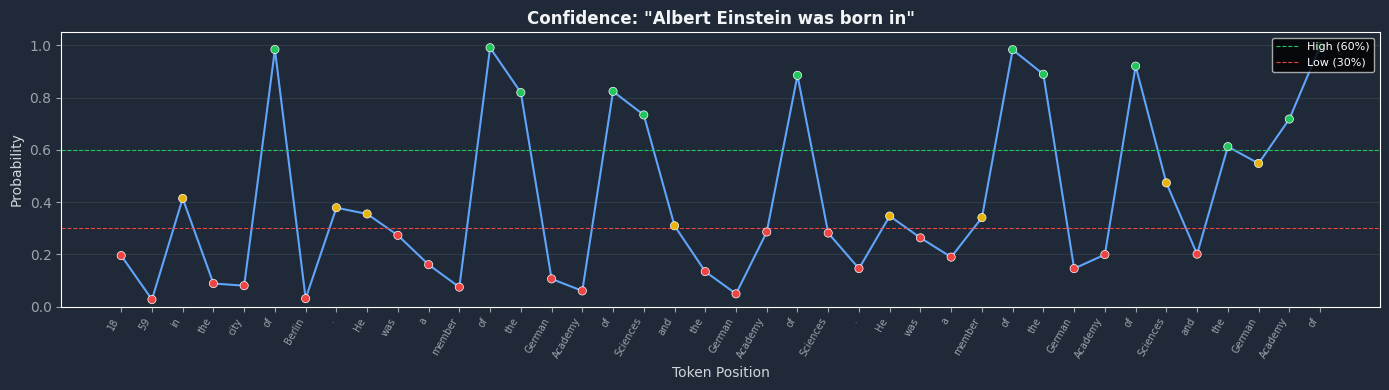

In [10]:
# Factual prompt -- the model starts confident but may hallucinate specific details
data1 = analyze_prompt("Albert Einstein was born in")

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


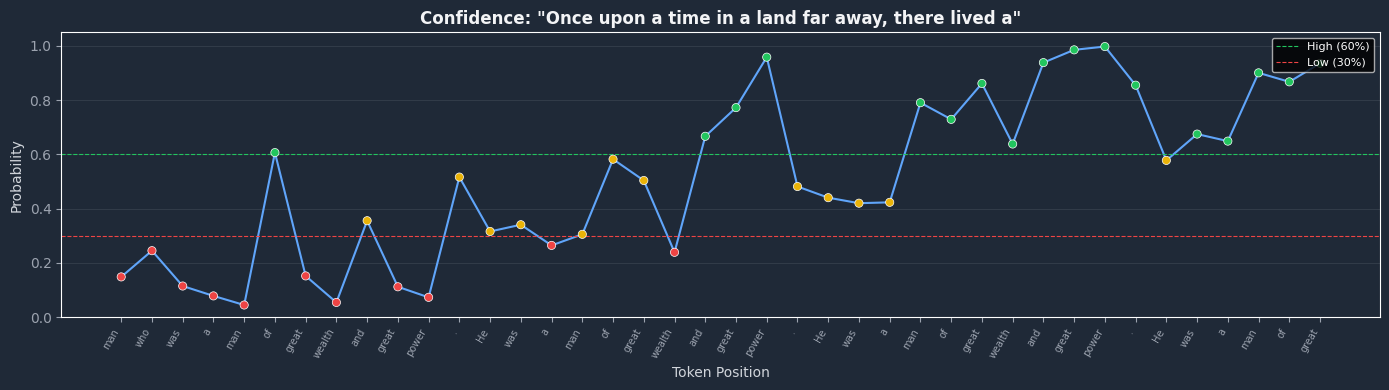

In [11]:
# Creative prompt -- generally lower and more variable confidence
data2 = analyze_prompt("Once upon a time in a land far away, there lived a")

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


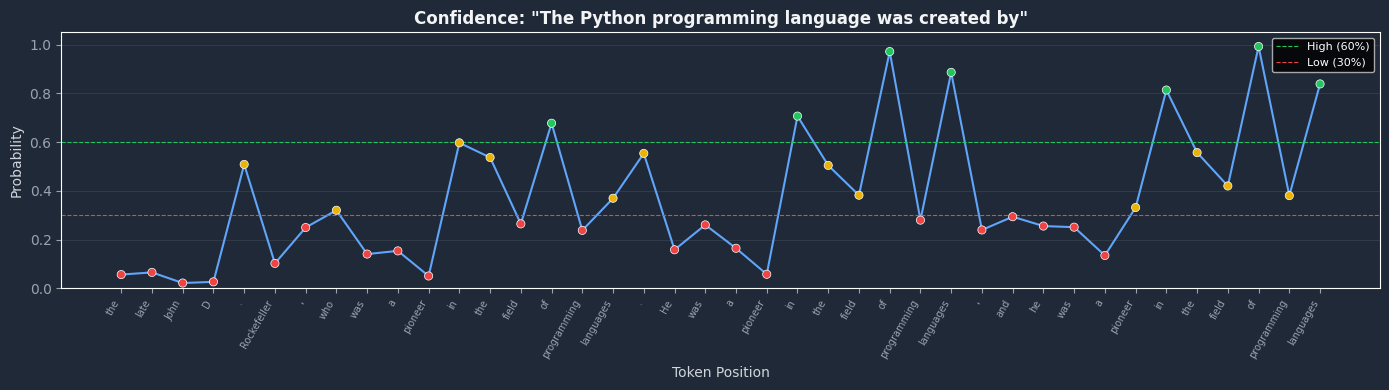

In [12]:
# Technical prompt -- confident on common patterns, uncertain on specifics
data3 = analyze_prompt("The Python programming language was created by")

## 10. The Key Insight

Look back at the visualizations above and notice:

- **Green tokens that are wrong** -- The model can be highly confident about incorrect facts. It might say a wrong date or name with 70%+ probability. These are **confident hallucinations** and they are the hardest to catch because the text reads naturally.

- **Red tokens that are right** -- Creative or uncommon phrasing often gets low confidence simply because it is rare in the training data, not because it is wrong.

- **Confidence drops on specifics** -- Models tend to be very confident on function words (the, is, of) and structure, but confidence drops sharply on specific facts like dates, numbers, and names. That is where hallucinations hide.

### Limitations

- Token probability alone cannot tell you whether something is factually correct
- These thresholds (60%, 30%) are heuristic, not scientifically calibrated
- GPT-2 is a small model; larger models like GPT-4 or LLaMA may show different patterns
- This approach visualizes uncertainty but does not perform fact-checking

### References

- Kadavath et al. (2022). *Language Models (Mostly) Know What They Know.* arXiv:2207.05221
- Lin, Hilton & Evans (2022). *Teaching Models to Express Their Uncertainty in Words.* arXiv:2205.14334
- Manakul, Liusie & Gales (2023). *SelfCheckGPT: Zero-Resource Black-Box Hallucination Detection.* arXiv:2303.08896

---

**Try your own prompts** by calling `analyze_prompt("Your text here")` in a new cell below.